# Multi-Task PINN (Option 2): Encoder → (θ, v0) + Classifier, Decoder sieht **kein z**
Dieses Notebook implementiert die Struktur, die wir besprochen haben:

- **Encoder** verarbeitet beobachtete Sequenzpunkte eines Wurfs → **Embedding** `z`
- **Parameter-Head**: `z → (θ, v0)` (mit Constraints wie im PINN-Notebook)
- **Decoder**: sagt Trajektorie voraus **nur aus** `(t, θ, v0, x0, y0)`  (**kein z**)
- **Classifier-Head**: `z → Klassenlogits`
- Loss: `data + physics + ic + cls`

> Erwartung an die CSV: mindestens Spalten `wurf_id, t, x, y, label`  
> Optional: `theta_true, v0_true` (nur zum Debug/Monitoring).

In [96]:
import os
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Konfiguration
Passe hier Pfad, Beobachtungslänge, Loss-Gewichte etc. an.

In [97]:
@dataclass
class Config:
    csv_path: str = "free_throw_clean_dataset.csv"  # <-- anpassen
    wurf_id_col: str = "wurf_id"
    t_col: str = "t"
    x_col: str = "x"
    y_col: str = "y"
    label_col: str = "label"  # <-- anpassen (int: 0..C-1)

    # Observation
    K_obs: int = 30
    min_points: int = 10

    # Physics
    g: float = 9.807
    h_korb: float = 3.048

    # Collocation sampling
    N_col: int = 64
    t_extra_min: float = 0.25
    t_extra_max: float = 3.0

    # Training
    batch_size: int = 32
    num_epochs: int = 500
    lr: float = 1e-3
    weight_decay: float = 0.0

    # Loss weights
    lam_data: float = 10.0
    lam_phys: float = 10.0
    lam_ic: float = 5.0
    lam_cls: float = 0.1

    # Model sizes
    d_model: int = 64
    d_latent: int = 64
    decoder_hidden: int = 128
    decoder_layers: int = 3

cfg = Config()
cfg

Config(csv_path='free_throw_clean_dataset.csv', wurf_id_col='wurf_id', t_col='t', x_col='x', y_col='y', label_col='label', K_obs=30, min_points=10, g=9.807, h_korb=3.048, N_col=64, t_extra_min=0.25, t_extra_max=3.0, batch_size=32, num_epochs=500, lr=0.001, weight_decay=0.0, lam_data=10.0, lam_phys=10.0, lam_ic=5.0, lam_cls=0.1, d_model=64, d_latent=64, decoder_hidden=128, decoder_layers=3)

## Daten laden & pro Wurf strukturieren
Wir erzeugen pro Wurf ein Sample:
- beobachtete Sequenz der ersten `K_obs` Punkte
- `t0` und `t_obs_max` zur Zeitnormalisierung (kein Leakage)
- Startpunkt `(x0,y0)` (1. beobachteter Punkt)
- Label `c`

In [98]:
df = pd.read_csv(cfg.csv_path)

required = {cfg.wurf_id_col, cfg.t_col, cfg.x_col, cfg.y_col, cfg.label_col}
missing = sorted(list(required - set(df.columns)))
if missing:
    raise ValueError(f"CSV fehlt Spalten: {missing}\nVorhanden: {list(df.columns)}")

df[cfg.wurf_id_col] = df[cfg.wurf_id_col].astype(int)
df = df.sort_values([cfg.wurf_id_col, cfg.t_col]).reset_index(drop=True)

n_classes = int(df[cfg.label_col].max()) + 1
print("Rows:", len(df), "Würfe:", df[cfg.wurf_id_col].nunique(), "Classes:", n_classes)
df.head()

Rows: 7500 Würfe: 150 Classes: 3


,wurf_id,t,x_clean,y_clean,x_noisy,y_noisy,x,y,T,label,theta,v0
0,0,0.000000,0.000000,2.662500,0.000000,2.662500,0.000000,2.662500,0.995387,2,0.795079,7.379223
1,0,0.020314,0.104965,2.767494,0.104965,2.767494,0.104965,2.767494,0.995387,2,0.795079,7.379223
2,0,0.040628,0.209931,2.868441,0.209931,2.868441,0.209931,2.868441,0.995387,2,0.795079,7.379223
3,0,0.060942,0.314896,2.965342,0.314896,2.965342,0.314896,2.965342,0.995387,2,0.795079,7.379223
4,0,0.081256,0.419862,3.058195,0.419862,3.058195,0.419862,3.058195,0.995387,2,0.795079,7.379223


In [99]:
class ThrowDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: Config):
        self.cfg = cfg
        self.samples: List[Dict] = []

        for wid, g in df.groupby(cfg.wurf_id_col):
            g = g.sort_values(cfg.t_col)
            t = g[cfg.t_col].to_numpy(dtype=np.float32)
            x = g[cfg.x_col].to_numpy(dtype=np.float32)
            y = g[cfg.y_col].to_numpy(dtype=np.float32)
            label = int(g[cfg.label_col].iloc[0])

            if len(t) < cfg.min_points:
                continue

            K = min(cfg.K_obs, len(t))
            t_obs, x_obs, y_obs = t[:K], x[:K], y[:K]

            t0 = float(t_obs[0])
            t_obs_max = float(t_obs[-1])
            t_scale = max(t_obs_max - t0, 1e-6)

            sample = dict(
                wurf_id=int(wid),
                t_obs=t_obs, x_obs=x_obs, y_obs=y_obs, K=K,
                t0=t0, t_obs_max=t_obs_max, t_scale=t_scale,
                x0=float(x_obs[0]), y0=float(y_obs[0]),
                label=label,
                t_full=t, x_full=x, y_full=y,
            )
            if "theta_true" in g.columns:
                sample["theta_true"] = float(g["theta_true"].iloc[0])
            if "v0_true" in g.columns:
                sample["v0_true"] = float(g["v0_true"].iloc[0])
            self.samples.append(sample)

        if len(self.samples) == 0:
            raise ValueError("Keine gültigen Samples gefunden. Prüfe Spaltennamen und min_points/K_obs.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict:
        return self.samples[idx]

def collate_fn(batch: List[Dict]) -> Dict[str, torch.Tensor]:
    maxK = max(b["K"] for b in batch)
    B = len(batch)

    t_obs = torch.zeros(B, maxK, 1, dtype=torch.float32)
    x_obs = torch.zeros(B, maxK, 1, dtype=torch.float32)
    y_obs = torch.zeros(B, maxK, 1, dtype=torch.float32)
    mask  = torch.zeros(B, maxK, 1, dtype=torch.float32)
    lengths = torch.tensor([b["K"] for b in batch], dtype=torch.long)

    t0 = torch.tensor([b["t0"] for b in batch], dtype=torch.float32)
    t_obs_max = torch.tensor([b["t_obs_max"] for b in batch], dtype=torch.float32)
    t_scale = torch.tensor([b["t_scale"] for b in batch], dtype=torch.float32)
    x0 = torch.tensor([b["x0"] for b in batch], dtype=torch.float32)
    y0 = torch.tensor([b["y0"] for b in batch], dtype=torch.float32)
    label = torch.tensor([b["label"] for b in batch], dtype=torch.long)
    wurf_id = torch.tensor([b["wurf_id"] for b in batch], dtype=torch.long)

    for i, b in enumerate(batch):
        K = b["K"]
        t_obs[i, :K, 0] = torch.from_numpy(b["t_obs"])
        x_obs[i, :K, 0] = torch.from_numpy(b["x_obs"])
        y_obs[i, :K, 0] = torch.from_numpy(b["y_obs"])
        mask[i, :K, 0] = 1.0

    return dict(
        wurf_id=wurf_id,
        t_obs=t_obs, x_obs=x_obs, y_obs=y_obs,
        mask=mask, lengths=lengths,
        t0=t0, t_obs_max=t_obs_max, t_scale=t_scale,
        x0=x0, y0=y0,
        label=label,
    )

dataset = ThrowDataset(df, cfg)
print("Samples:", len(dataset))

idx = np.arange(len(dataset))
np.random.shuffle(idx)
split = int(0.8 * len(idx))
train_idx, val_idx = idx[:split], idx[split:]

train_ds = torch.utils.data.Subset(dataset, train_idx.tolist())
val_ds   = torch.utils.data.Subset(dataset, val_idx.tolist())

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, collate_fn=collate_fn, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_fn, drop_last=False)

len(train_loader), len(val_loader)

Samples: 150


(3, 1)

## Modell: Encoder → Parameter-Head & Class-Head; Decoder ohne z
Encoder-Input pro Punkt: `(t_norm, x, y)` mit `t_norm=(t-t0)/t_scale`.
Decoder-Input: `(t_norm, sinθ, cosθ, v0, x0, y0)`.

In [100]:
class GRUEncoder(nn.Module):
    def __init__(self, d_in: int, d_hidden: int, d_latent: int):
        super().__init__()
        self.gru = nn.GRU(input_size=d_in, hidden_size=d_hidden, batch_first=True)
        self.proj = nn.Linear(d_hidden, d_latent)

    def forward(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, h = self.gru(packed)        # h: [1,B,d_hidden]
        h = h.squeeze(0)              # [B,d_hidden]
        return self.proj(h)           # [B,d_latent]

class ParamHead(nn.Module):
    def __init__(self, d_latent: int):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_latent, 64), nn.Tanh(), nn.Linear(64, 2))

    def forward(self, z: torch.Tensor):
        raw = self.net(z)
        theta_raw, v0_raw = raw[:, 0], raw[:, 1]
        theta = 0.5 * math.pi * torch.sigmoid(theta_raw)   # (0, pi/2)
        v0    = F.softplus(v0_raw) + 1e-6                  # >0
        return theta, v0

class ClassHead(nn.Module):
    def __init__(self, d_latent: int, n_classes: int):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_latent, 64), nn.ReLU(), nn.Linear(64, n_classes))

    def forward(self, z: torch.Tensor):
        return self.net(z)

class DecoderMLP(nn.Module):
    def __init__(self, d_in: int, hidden: int = 128, layers: int = 3):
        super().__init__()
        mods = []
        dims = [d_in] + [hidden]*layers + [2]
        for i in range(len(dims)-2):
            mods += [nn.Linear(dims[i], dims[i+1]), nn.Tanh()]
        mods += [nn.Linear(dims[-2], dims[-1])]
        self.net = nn.Sequential(*mods)

    def forward(self, inp: torch.Tensor):
        return self.net(inp)

def safe_time_to_height(theta: torch.Tensor, v0: torch.Tensor, y0: torch.Tensor, h: float, g: float) -> torch.Tensor:
    a = -0.5 * g
    b = v0 * torch.sin(theta)
    c = y0 - h
    disc = b*b - 4*a*c
    disc_clamped = torch.clamp(disc, min=0.0)
    sqrt_disc = torch.sqrt(disc_clamped)
    denom = 2*a
    t1 = (-b - sqrt_disc) / denom
    t2 = (-b + sqrt_disc) / denom
    t = torch.maximum(t1, t2)
    t = torch.where(disc >= 0, t, torch.full_like(t, float("nan")))
    return t

class MultiTaskPINN(nn.Module):
    def __init__(self, n_classes: int, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.encoder = GRUEncoder(d_in=3, d_hidden=cfg.d_model, d_latent=cfg.d_latent)
        self.param_head = ParamHead(cfg.d_latent)
        self.class_head = ClassHead(cfg.d_latent, n_classes)
        self.decoder = DecoderMLP(d_in=6, hidden=cfg.decoder_hidden, layers=cfg.decoder_layers)

    def encode(self, t_obs, x_obs, y_obs, lengths, t0, t_scale):
        t_norm = (t_obs[..., 0] - t0[:, None]) / t_scale[:, None]
        feats = torch.cat([t_norm[..., None], x_obs, y_obs], dim=-1)  # [B,K,3]
        return self.encoder(feats, lengths)

    def forward(self, batch: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
        t_obs = batch["t_obs"].to(device)
        x_obs = batch["x_obs"].to(device)
        y_obs = batch["y_obs"].to(device)
        lengths = batch["lengths"].to(device)
        t0 = batch["t0"].to(device)
        t_scale = batch["t_scale"].to(device)

        z = self.encode(t_obs, x_obs, y_obs, lengths, t0, t_scale)
        theta, v0 = self.param_head(z)
        logits = self.class_head(z)
        return dict(z=z, theta=theta, v0=v0, logits=logits)

    def traj(self, t_real, theta, v0, x0, y0, t0, t_scale):
        # NEU: reale Zeitdifferenz
        tau = (t_real[..., 0] - t0[:, None])  # [B,N]

        B, N, _ = t_real.shape
        sinth = torch.sin(theta)[:, None]
        costh = torch.cos(theta)[:, None]
        v0b = v0[:, None]
        x0b = x0[:, None]
        y0b = y0[:, None]

        inp = torch.cat([
            tau[..., None],                        # <-- statt t_norm
            sinth[:, None, :].expand(B, N, 1),
            costh[:, None, :].expand(B, N, 1),
            v0b[:, None, :].expand(B, N, 1),
            x0b[:, None, :].expand(B, N, 1),
            y0b[:, None, :].expand(B, N, 1),
        ], dim=-1)  # [B,N,6]
        return self.decoder(inp)


model = MultiTaskPINN(n_classes=n_classes, cfg=cfg).to(device)
sum(p.numel() for p in model.parameters())/1e6

0.060231

## Loss-Funktionen (data + phys + ic + cls)
Physics: 1.-Ordnung-Residuals wie in deinem Notebook:
- x'(t) = v0 cos(theta)
- y'(t) = v0 sin(theta) - g*(t - t0)

In [101]:
def masked_mse(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    diff2 = (pred - target) ** 2
    diff2 = diff2 * mask
    return diff2.sum() / (mask.sum() * diff2.shape[-1] + 1e-9)

def sample_collocation_times(theta, v0, y0, t0, t_obs_max, cfg: Config):
    B = theta.shape[0]
    t_hit = safe_time_to_height(theta, v0, y0, h=cfg.h_korb, g=cfg.g)  # delta from t0

    fallback = (t_obs_max + cfg.t_extra_max) - t0
    t_hit = torch.where(torch.isnan(t_hit), fallback, t_hit)
    t_hit_abs = t0 + t_hit

    t_end_min = t_obs_max + cfg.t_extra_min
    t_end_max = t_obs_max + cfg.t_extra_max
    t_end = torch.clamp(t_hit_abs, min=t_end_min, max=t_end_max)

    u = torch.rand(B, cfg.N_col, 1, device=theta.device)
    t_real = t0[:, None, None] + u * (t_end[:, None, None] - t0[:, None, None])
    return t_real


def physics_loss(
    model: MultiTaskPINN,
    t_col,
    theta,
    v0,
    x0,
    y0,
    t0,
    t_scale,
    cfg: Config,
    create_graph: bool,
):
    # Wichtig: grad mode auch in eval/val aktivieren
    with torch.enable_grad():
        t_col = t_col.detach().clone().requires_grad_(True)

        xy_hat = model.traj(t_col, theta, v0, x0, y0, t0, t_scale)  # [B,N,2]
        x_hat = xy_hat[..., 0:1]
        y_hat = xy_hat[..., 1:2]

        dx_dt = torch.autograd.grad(
            x_hat,
            t_col,
            grad_outputs=torch.ones_like(x_hat),
            create_graph=create_graph,
            retain_graph=create_graph,
        )[0]
        dy_dt = torch.autograd.grad(
            y_hat,
            t_col,
            grad_outputs=torch.ones_like(y_hat),
            create_graph=create_graph,
            retain_graph=create_graph,
        )[0]

        v0b = v0[:, None, None]
        costh = torch.cos(theta)[:, None, None]
        sinth = torch.sin(theta)[:, None, None]
        tau = (t_col[..., 0] - t0[:, None])[:, :, None]

        rx = dx_dt - v0b * costh
        ry = dy_dt - (v0b * sinth - cfg.g * tau)

        return (rx**2 + ry**2).mean()


def ic_loss(model: MultiTaskPINN, theta, v0, x0, y0, t0, t_scale):
    t0_real = t0[:, None, None]
    xy0_hat = model.traj(t0_real, theta, v0, x0, y0, t0, t_scale)
    x_hat0 = xy0_hat[:, 0, 0]
    y_hat0 = xy0_hat[:, 0, 1]
    return ((x_hat0 - x0)**2 + (y_hat0 - y0)**2).mean()

## Training

In [102]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

history = {k: [] for k in [
    "train_total","train_data","train_phys","train_ic","train_cls","train_acc",
    "val_total","val_data","val_phys","val_ic","val_cls","val_acc"
]}

def run_epoch(loader: DataLoader, train: bool):
    model.train() if train else model.eval()

    tot_total = tot_data = tot_phys = tot_ic = tot_cls = 0.0
    correct = total = 0

    for batch in loader:
        # move
        batch = {k: v.to(device) for k, v in batch.items()}

        t_obs = batch["t_obs"]
        x_obs = batch["x_obs"]
        y_obs = batch["y_obs"]
        mask  = batch["mask"]
        t0 = batch["t0"]
        t_obs_max = batch["t_obs_max"]
        t_scale = batch["t_scale"]
        x0 = batch["x0"]
        y0 = batch["y0"]
        label = batch["label"]

        with torch.set_grad_enabled(train):
            out = model(batch)
            theta, v0, logits = out["theta"], out["v0"], out["logits"]

            xy_hat_obs = model.traj(t_obs, theta, v0, x0, y0, t0, t_scale)
            x_hat = xy_hat_obs[..., 0:1]
            y_hat = xy_hat_obs[..., 1:2]
            L_data = masked_mse(x_hat, x_obs, mask) + masked_mse(y_hat, y_obs, mask)

            t_col = sample_collocation_times(theta, v0, y0, t0, t_obs_max, cfg)
            L_phys = physics_loss(
                model, t_col, theta, v0, x0, y0, t0, t_scale, cfg, create_graph=True
            )

            L_ic = ic_loss(model, theta, v0, x0, y0, t0, t_scale)

            L_cls = F.cross_entropy(logits, label)

            L_total = cfg.lam_data*L_data + cfg.lam_phys*L_phys + cfg.lam_ic*L_ic + cfg.lam_cls*L_cls

            if train:
                optimizer.zero_grad(set_to_none=True)
                L_total.backward()
                optimizer.step()

        tot_total += float(L_total.detach().cpu())
        tot_data  += float(L_data.detach().cpu())
        tot_phys  += float(L_phys.detach().cpu())
        tot_ic    += float(L_ic.detach().cpu())
        tot_cls   += float(L_cls.detach().cpu())

        pred = torch.argmax(logits, dim=1)
        correct += int((pred == label).sum().detach().cpu())
        total   += int(label.numel())

    n = max(len(loader), 1)
    return dict(
        total=tot_total/n, data=tot_data/n, phys=tot_phys/n, ic=tot_ic/n, cls=tot_cls/n,
        acc=correct/max(total,1)
    )

for epoch in range(1, cfg.num_epochs+1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)

    history["train_total"].append(tr["total"]); history["train_data"].append(tr["data"]); history["train_phys"].append(tr["phys"])
    history["train_ic"].append(tr["ic"]); history["train_cls"].append(tr["cls"]); history["train_acc"].append(tr["acc"])

    history["val_total"].append(va["total"]); history["val_data"].append(va["data"]); history["val_phys"].append(va["phys"])
    history["val_ic"].append(va["ic"]); history["val_cls"].append(va["cls"]); history["val_acc"].append(va["acc"])

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | "
              f"train total {tr['total']:.4f} (data {tr['data']:.4f}, phys {tr['phys']:.4f}, ic {tr['ic']:.4f}, cls {tr['cls']:.4f}, acc {tr['acc']:.3f}) | "
              f"val total {va['total']:.4f} (acc {va['acc']:.3f})")

Epoch 001 | train total 4022.4519 (data 13.5464, phys 385.5191, ic 6.3375, cls 1.0885, acc 0.469) | val total 3902.8750 (acc 0.600)
Epoch 005 | train total 2813.8491 (data 1.5943, phys 278.3613, ic 2.8380, cls 1.0303, acc 0.458) | val total 1999.0438 (acc 0.600)
Epoch 010 | train total 126.5043 (data 1.6030, phys 8.8950, ic 4.2846, cls 1.0066, acc 0.490) | val total 106.8215 (acc 0.600)
Epoch 015 | train total 63.7413 (data 1.0025, phys 4.7303, ic 1.2625, cls 1.0057, acc 0.510) | val total 62.5445 (acc 0.600)
Epoch 020 | train total 62.3683 (data 1.0652, phys 4.6560, ic 1.0115, cls 0.9849, acc 0.510) | val total 63.0849 (acc 0.600)
Epoch 025 | train total 59.9051 (data 1.1023, phys 4.3727, ic 1.0106, cls 1.0233, acc 0.469) | val total 59.3612 (acc 0.600)
Epoch 030 | train total 61.1472 (data 1.0396, phys 4.2037, ic 1.7222, cls 1.0355, acc 0.490) | val total 61.7999 (acc 0.600)
Epoch 035 | train total 59.0923 (data 1.3572, phys 4.1598, ic 0.7640, cls 1.0139, acc 0.479) | val total 57.55

## Plots

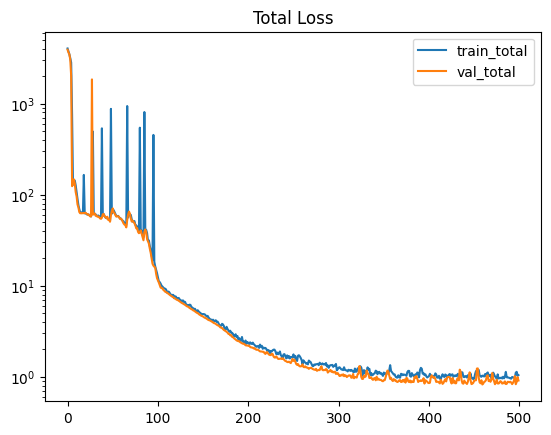

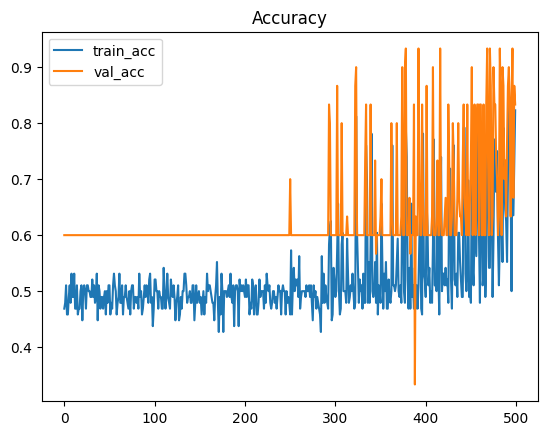

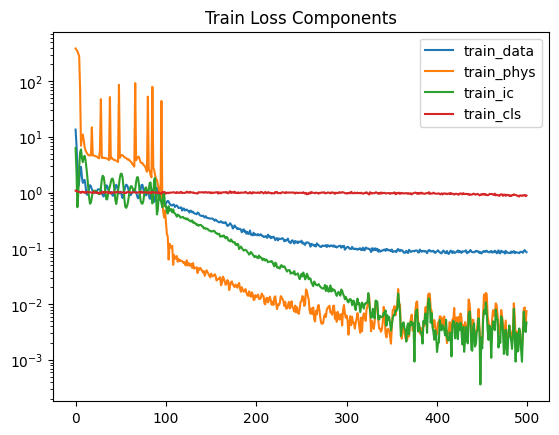

In [103]:
plt.figure()
plt.plot(history["train_total"], label="train_total")
plt.plot(history["val_total"], label="val_total")
plt.yscale("log")
plt.legend(); plt.title("Total Loss"); plt.show()

plt.figure()
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend(); plt.title("Accuracy"); plt.show()

plt.figure()
plt.plot(history["train_data"], label="train_data")
plt.plot(history["train_phys"], label="train_phys")
plt.plot(history["train_ic"], label="train_ic")
plt.plot(history["train_cls"], label="train_cls")
plt.yscale("log")
plt.legend(); plt.title("Train Loss Components"); plt.show()

## Visualisierung: ein Beispielwurf (Trajektorie)

wurf_id: 91
pred class: 2 logits: [ 0.15003388 -0.5657804   0.38749143]
theta_hat: 0.8909741640090942 rad | deg: 51.049059252917914
v0_hat: 6.671810150146484
true theta id 91: 1.015140404052279 rad | deg: 58.16326076540067
true v0 id 91: 7.261823537639876


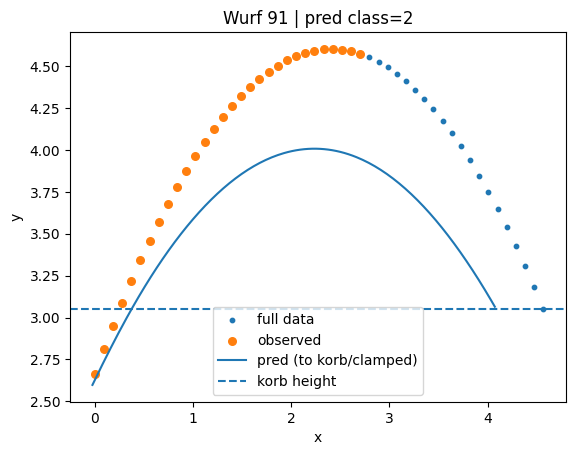

In [107]:
sample_idx = int(val_idx[0]) if len(val_idx) > 0 else 0
sample = dataset.samples[sample_idx]

# single-sample batch
b = collate_fn([sample])
b = {k: v.to(device) for k, v in b.items()}

model.eval()
with torch.no_grad():
    out = model(b)

theta_hat = out["theta"].detach().cpu().item()
v0_hat = out["v0"].detach().cpu().item()
logits = out["logits"].detach().cpu().numpy()[0]
pred_class = int(np.argmax(logits))

print("wurf_id:", sample["wurf_id"])
print("pred class:", pred_class, "logits:", logits)
print("theta_hat:", theta_hat, "rad | deg:", theta_hat*180/math.pi)
print("v0_hat:", v0_hat)
print("true theta id 91:", 1.015140404052279, "rad | deg:", 1.015140404052279*180/math.pi)
print("true v0 id 91:", 7.261823537639876)

t0 = sample["t0"]
t_obs_max = sample["t_obs_max"]
y0 = sample["y0"]

theta_t = torch.tensor([theta_hat], device=device)
v0_t = torch.tensor([v0_hat], device=device)
y0_t = torch.tensor([y0], device=device)

t_hit = safe_time_to_height(theta_t, v0_t, y0_t, cfg.h_korb, cfg.g).cpu().numpy()[0]
if np.isnan(t_hit):
    t_end = t_obs_max + cfg.t_extra_max
else:
    t_end = t0 + t_hit
t_end = float(np.clip(t_end, t_obs_max + cfg.t_extra_min, t_obs_max + cfg.t_extra_max))

t_grid = np.linspace(t0, t_end, 200, dtype=np.float32)
t_grid_t = torch.from_numpy(t_grid[None, :, None]).to(device)

with torch.no_grad():
    xy_hat = model.traj(t_grid_t, out["theta"], out["v0"], b["x0"], b["y0"], b["t0"], b["t_scale"]).cpu().numpy()[0]

plt.figure()
plt.scatter(sample["x_full"], sample["y_full"], s=10, label="full data")
plt.scatter(sample["x_obs"], sample["y_obs"], s=30, label="observed")
plt.plot(xy_hat[:,0], xy_hat[:,1], label="pred (to korb/clamped)")
plt.axhline(cfg.h_korb, linestyle="--", label="korb height")
plt.xlabel("x"); plt.ylabel("y"); plt.legend()
plt.title(f"Wurf {sample['wurf_id']} | pred class={pred_class}")
plt.show()

## Hinweise / typische Anpassungen
- Wenn dein Label anders heißt: `cfg.label_col` anpassen.
- Falls du statt `(t,x,y)` nur `(t,y)` nutzt: Encoder-Inputdim ändern (d_in=2).
- Wenn `t` nicht bei 0 startet: hier wird immer relativ zu `t0` gearbeitet → konsistent.
- Falls du Ground Truth `theta_true/v0_true` hast, kannst du optional eine Zusatzloss einbauen.